In [1]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
LAYERS = (256, 256, 256)

p_exit, gamma = 0.4, 1.4

x_throat = 0.5  # x_length = 1.0
R_in, R_throat, R_out = map(lambda x: np.sqrt(x / np.pi), (9, 1, 4))
maximum_temp = 5.0
wall_delta = 0.05 # This is how close any points needs to be to be on the wall
external_delta = 1e-5 # This is how close any points needs to be to be on inlet/exit/throat

In [4]:
class FNNonConstraints(nn.Module):
    def __init__(self, layers, num_inputs=2, num_outputs=4):
        super().__init__()

        modules = []
        in_dim = num_inputs
        for h in layers:
            modules.append(nn.Linear(in_dim, h))
            modules.append(nn.Tanh())
            in_dim = h

        modules.append(nn.Linear(in_dim, num_outputs))
        self.net = nn.Sequential(*modules)

        # remove bias and set kaimimng normal with tanh nonlinearity
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                nn.init.zeros_(m.bias)

    def forward(self, xt):
        out = self.net(xt)
        return FNNonConstraints.apply_pressure_linearization(xt, out)

    @staticmethod
    def apply_pressure_linearization(points: torch.Tensor, outputs: torch.Tensor):
        rho, u, p, T = outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3], outputs[:, 3:4]
        x = points[:, 0:1]

        hard_p = x * (x - 1.0) * p + (1 - (1.0 - p_exit) * x)
        #        ^----^ 0 at in/exit, ^ 1 at inlet, linear in between, p_exit at exit

        return torch.cat([rho, u, hard_p, T], dim=1)

In [5]:
def get_radius_at_a_distance(x: torch.Tensor) -> torch.Tensor:
    t_convergent = x / x_throat
    t_divergent = (x - x_throat) / (1.0 - x_throat)

    r_conv = R_in + (R_throat - R_in) * (3 * t_convergent**2 - 2 * t_convergent**3)
    r_div = R_throat + (R_out - R_throat) * (3 * t_divergent**2 - 2 * t_divergent**3)

    return torch.where(x < x_throat, r_conv, r_div)


def get_area(x: torch.Tensor) -> torch.Tensor:
    return torch.pi * get_radius_at_a_distance(x) ** 2


def generate_nozzle_points(n=1000, boundary_qty=0.03):
    interior_nums = int(n * (1 - boundary_qty))
    boundary_nums = int(n * boundary_qty) // 4  # inlet, outlet, throat, IC

    interior_x = torch.rand(interior_nums, 1, device=device, dtype=torch.float32)
    inlet_x    = torch.zeros(boundary_nums, 1, device=device, dtype=torch.float32)
    outlet_x   = torch.ones(boundary_nums, 1, device=device, dtype=torch.float32)
    throat_x   = torch.full((boundary_nums, 1), x_throat, device=device, dtype=torch.float32)
    ic_x       = torch.rand(boundary_nums, 1, device=device, dtype=torch.float32)

    interior_t = torch.rand(interior_nums, 1, device=device, dtype=torch.float32) * maximum_temp

    inlet_t    = torch.rand(boundary_nums, 1, device=device, dtype=torch.float32) * maximum_temp
    outlet_t   = torch.rand(boundary_nums, 1, device=device, dtype=torch.float32) * maximum_temp
    throat_t   = torch.rand(boundary_nums, 1, device=device, dtype=torch.float32) * maximum_temp

    ic_t       = torch.zeros(boundary_nums, 1, device=device, dtype=torch.float32)

    all_points = torch.cat([
        torch.cat([interior_x, interior_t], dim=1),
        torch.cat([inlet_x,    inlet_t],    dim=1),
        torch.cat([outlet_x,   outlet_t],   dim=1),
        torch.cat([throat_x,   throat_t],   dim=1),
        torch.cat([ic_x,       ic_t],       dim=1),
    ], dim=0)  # shape: [n, 2]

    return all_points.requires_grad_(True)

In [6]:
# def _mk_tensor(type, *args, **kwargs) -> torch.Tensor:
#     if type == "zeros":
#         return torch.zeros(
#             *args, dtype=torch.float32, device=device, requires_grad=True, **kwargs
#         )
#     elif type == "ones":
#         return torch.ones(
#             *args, dtype=torch.float32, device=device, requires_grad=True, **kwargs
#         )
#     elif type == "linspace":
#         return torch.linspace(
#             *args, dtype=torch.float32, device=device, requires_grad=True, **kwargs
#         )
#     elif type == "rand":
#         return torch.rand(
#             *args, dtype=torch.float32, device=device, requires_grad=True, **kwargs
#         )
#     return torch.tensor(
#         *args, dtype=torch.float32, device=device, requires_grad=True, **kwargs
#     )
# 
# def generate_nozzle_points(
#     N_interior=1000,
#     N_inlet=100,
#     N_outlet=100,
#     N_wall=200,
#     N_center=100,
# ):
#     inlet_pts = torch.hstack(
#         [
#             _mk_tensor("zeros", (N_inlet, 1)),
#             _mk_tensor("linspace", -R_in, R_in, N_inlet)[:, None],
#         ]
#     )

#     outlet_pts = torch.hstack(
#         [
#             _mk_tensor("ones", (N_outlet, 1)),
#             _mk_tensor("linspace", -R_out, R_out, N_outlet)[:, None],
#         ]
#     )

#     center_pts = torch.hstack(
#         [
#             _mk_tensor("linspace", 0, 1, N_center)[:, None],
#             _mk_tensor("zeros", (N_center, 1)),
#         ]
#     )

#     wall_x = _mk_tensor("linspace", 0, 1, N_wall)
#     wall_pts = torch.hstack(
#         [
#             wall_x[:, None],
#             get_radius_at_a_distance(wall_x)[:, None],
#         ]
#     )

#     random_interior_points = _mk_tensor("rand", N_interior, 2)
#     wall_limits = get_radius_at_a_distance(random_interior_points[:, 0])
#     interior_pts = torch.hstack(
#         [
#             random_interior_points[:, 0][:, None],
#             (random_interior_points[:, 1] * wall_limits)[:, None],
#         ]
#     )

#     points = torch.cat(
#         [interior_pts, inlet_pts, outlet_pts, wall_pts, center_pts],
#         dim=0,
#     )
#     points.requires_grad_(True)
#     return points

In [7]:
def d_(f, x):
    return torch.autograd.grad(
        f, x, grad_outputs=torch.ones_like(f), create_graph=True
    )[0]


def model_grads(model: FNNonConstraints, xt: torch.Tensor):
    outputs = model(xt)
    rho, u, p, T = outputs[:, 0:1], outputs[:, 1:2], outputs[:, 2:3], outputs[:, 3:4]
    x, t = xt[:, 0:1], xt[:, 1:2]
    A = get_area(x)

    rho_grad, u_grad, p_grad, T_grad = d_(rho, xt), d_(u, xt), d_(p, xt), d_(T, xt)
    rho_x, rho_t = rho_grad[:, 0:1], rho_grad[:, 1:2]
    u_x, u_t = u_grad[:, 0:1], u_grad[:, 1:2]
    T_x, T_t = T_grad[:, 0:1], T_grad[:, 1:2]
    p_x = p_grad[:, 0:1]
    A_x = d_(A, x)

    return {
        "x": x,
        "t": t,
        "rho": rho,
        "u": u,
        "p": p,
        "T": T,
        "A": A,
        "rho_x": rho_x,
        "rho_t": rho_t,
        "u_x": u_x,
        "u_t": u_t,
        "T_x": T_x,
        "T_t": T_t,
        "p_x": p_x,
        "A_x": A_x,
    }

In [8]:
def pde_residuals(gradients: dict[str, torch.Tensor]):
    rho, u, p, T, A = (
        gradients["rho"],
        gradients["u"],
        gradients["p"],
        gradients["T"],
        gradients["A"],
    )

    rho_x, u_x, p_x, T_x, A_x = (
        gradients["rho_x"],
        gradients["u_x"],
        gradients["p_x"],
        gradients["T_x"],
        gradients["A_x"],
    )

    rho_t, u_t, T_t = (
        gradients["rho_t"],
        gradients["u_t"],
        gradients["T_t"],
    )

    mass = A * rho_t + A * u * rho_x + A * rho * u_x + rho * u * A_x
    momentum = A * (gamma * rho * (u_t + u * u_x) + p_x)
    energy = rho * A * (T_t + u * T_x) + (gamma - 1) * p * (A * u_x + A_x * u)
    ideal = p - rho * T

    return (
        mass.pow(2).mean()
        + momentum.pow(2).mean() * 20.0
        + energy.pow(2).mean()
        + ideal.pow(2).mean()
    )


def boundary_residuals(gradients: dict[str, torch.Tensor]):
    x, t, rho, u, p, T = (
        gradients["x"],
        gradients["t"],
        gradients["rho"],
        gradients["u"],
        gradients["p"],
        gradients["T"],
    )

    inlet_x_mask = x[:, 0] < external_delta
    inlet_rho_residual = rho[inlet_x_mask] - 1.0
    inlet_p_residual = p[inlet_x_mask] - 1.0
    inlet_T_residual = T[inlet_x_mask] - 1.0

    initial_t_mask = t[:, 0] < external_delta
    initial_rho_residual = rho[initial_t_mask] - 1.0
    initial_u_residual = u[initial_t_mask] - 0.0
    initial_p_residual = p[initial_t_mask] - 1.0
    initial_T_residual = T[initial_t_mask] - 1.0

    outlet_mask = x[:, 0] > 1.0 - external_delta
    outlet_p_residual = p[outlet_mask] - p_exit

    # wall boundary conditions and center flow conditions in the absence of y?

    return (
        inlet_rho_residual.pow(2).mean()
        + inlet_p_residual.pow(2).mean()
        + inlet_T_residual.pow(2).mean()
        + initial_rho_residual.pow(2).mean()
        + initial_u_residual.pow(2).mean()
        + initial_p_residual.pow(2).mean()
        + initial_T_residual.pow(2).mean()
        + outlet_p_residual.pow(2).mean()
    )


def total_loss(model: FNNonConstraints, points: torch.Tensor):
    gradients = model_grads(model, points)
    pde_losses = pde_residuals(gradients)
    boundary_loss = boundary_residuals(gradients)

    return pde_losses + 10.0 * boundary_loss, pde_losses, boundary_loss

In [9]:
from typing import Optional
from pathlib import Path
from datetime import datetime
from copy import deepcopy
import os


class ModelSave:
    SAVE_DIR_NAME = "saved_models_pinn"

    def __init__(self):
        file = os.path.dirname(os.path.abspath("__file__"))
        self.save_dir = Path(file).joinpath(self.SAVE_DIR_NAME)
        self.save_dir.mkdir(exist_ok=True)

    def generate_save_path(self, suffix: Optional[str] = None) -> str:
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        model_name = f"hybrid-qpinn-v2-{timestamp}"
        if suffix:
            model_name += f"-{suffix}"
        return str(self.save_dir.joinpath(model_name + ".pt"))

    @staticmethod
    def snapshot(model: nn.Module):
        return deepcopy(model.state_dict())

    @staticmethod
    def restore(model: nn.Module, snapshot: dict):
        model.load_state_dict(snapshot)

    @staticmethod
    def update_best(
        model: nn.Module,
        current_loss: float,
        best_loss: Optional[float],
        best_snapshot: Optional[dict],
    ):
        if best_loss is None or current_loss < best_loss:
            return current_loss, ModelSave.snapshot(model)
        return best_loss, best_snapshot

    @staticmethod
    def save(model: nn.Module, path: str):
        model_state = ModelSave.snapshot(model)

        torch.save(model_state, path)
        print(f"Model saved to {path}")

    @staticmethod
    def load(path: str):
        if not os.path.exists(path):
            raise FileNotFoundError(f"No model found at {path}")

        model = FNNonConstraints(layers=LAYERS).to(device)
        model_state = torch.load(path, map_location=device)
        ModelSave.restore(model, model_state)
        print(f"Model loaded from {path}")
        return model

In [10]:
from typing import TypedDict


class AdamParams(TypedDict):
    epochs: int
    print_freq: int
    resample_every: int
    lr: float


def use_adam_optimizer(
    model: FNNonConstraints,
    params: AdamParams,
    history: list[tuple[float, float, float]],
    best_loss: Optional[float],
    best_state: Optional[dict],
):
    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"])

    print("starting training [Adam] optimizer...")
    for epoch in range(params["epochs"]):
        if epoch % params["resample_every"] == 0:
            points = generate_nozzle_points()

        optimizer.zero_grad()
        loss, pde_loss, boundary_loss = total_loss(model, points)  # type: ignore

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        best_loss, best_state = ModelSave.update_best(
            model, loss.item(), best_loss, best_state
        )

        history.append((pde_loss.item(), boundary_loss.item(), loss.item()))
        if (epoch + 1) % params["print_freq"] == 0:
            print(
                f"Epoch {epoch+1:<{len(str(params['epochs']))}}/{params['epochs']}, PDE Loss: {pde_loss.item():.6f}, Boundary Loss: {boundary_loss.item():.6f}, Total Loss: {loss.item():.6f}"
            )

    return best_loss, best_state, history

In [11]:
class LBFGSParams(TypedDict):
    epochs: int
    print_freq: int


def use_lbfgs_optimizer(
    model: FNNonConstraints,
    params: LBFGSParams,
    history: list[tuple[float, float, float]],
    best_loss: Optional[float],
    best_state: Optional[dict],
):
    optimizer = torch.optim.LBFGS(model.parameters(), line_search_fn="strong_wolfe")
    points = generate_nozzle_points()
    last_iter = {}

    def closure():
        optimizer.zero_grad()
        loss, pde_loss, boundary_loss = total_loss(model, points)
        loss.backward()

        last_iter["total"], last_iter["pde_loss"], last_iter["boundary_loss"] = (
            loss.item(),
            pde_loss.item(),
            boundary_loss.item(),
        )
        return loss

    print("starting training [LBFGS] optimizer...")
    for epoch in range(params["epochs"]):
        loss = optimizer.step(closure)
        best_loss, best_state = ModelSave.update_best(
            model, loss.item(), best_loss, best_state
        )

        history.append(
            (last_iter["pde_loss"], last_iter["boundary_loss"], last_iter["total"])
        )
        if (epoch + 1) % params["print_freq"] == 0:
            print(
                f"Epoch {epoch+1:<{len(str(params['epochs']))}}/{params['epochs']}, PDE Loss: {last_iter['pde_loss']:.6f}, Boundary Loss: {last_iter['boundary_loss']:.6f}, Total Loss: {last_iter['total']:.6f}"
            )

    return best_loss, best_state, history

In [12]:
def train(
    model: FNNonConstraints,
    adam_params: AdamParams,
    lbfgs_params: LBFGSParams,
):
    best_loss, best_state = float("inf"), None
    history = []

    adam_result = use_adam_optimizer(model, adam_params, history, best_loss, best_state)
    if adam_result is None:
        raise ValueError("use_adam_optimizer returned None")

    best_loss, best_state, history = adam_result
    if best_state is not None:
        ModelSave.restore(model, best_state)
    print("[Adam] optimizer ran.", end=" ")
    ModelSave.save(model, ModelSave().generate_save_path("adam"))
    print(f"[Adam] model saved (loss: {best_loss:.6f})")

    lbfgs_result = use_lbfgs_optimizer(
        model, lbfgs_params, history, best_loss, best_state
    )
    if lbfgs_result is None:
        raise ValueError("use_lbfgs_optimizer returned None")

    best_loss, best_state, history = lbfgs_result
    if best_state is not None:
        ModelSave.restore(model, best_state)
    print("[LBFGS] optimizer ran.", end=" ")
    ModelSave.save(model, ModelSave().generate_save_path("lbfgs"))
    print(f"[LBFGS] model saved (loss: {best_loss:.6f})")

    return history

In [13]:
model = FNNonConstraints(layers=LAYERS).to(device)

{
    "total params": sum(p.numel() for p in model.parameters()),
    "trainable params": sum(p.numel() for p in model.parameters() if p.requires_grad),
}

{'total params': 133380, 'trainable params': 133380}

In [14]:
loss_history = train(
    model,
    {"epochs": 4000, "print_freq": 500, "resample_every": 100, "lr": 1e-3},
    {"epochs": 300, "print_freq": 40},
)

starting training [Adam] optimizer...
Epoch 500 /4000, PDE Loss: 13.724342, Boundary Loss: 0.202262, Total Loss: 15.746958
Epoch 1000/4000, PDE Loss: 4.817030, Boundary Loss: 0.028619, Total Loss: 5.103225


KeyboardInterrupt: 

In [ ]:
from scipy.interpolate import interp1d
import pandas as pd

model.eval()

x_lin = torch.linspace(0, 1, 1000, device=device)[:, None]
t = torch.full((1000, 1), maximum_temp, device=device)
eval_points = torch.cat([x_lin, t], dim=1).requires_grad_(True)
with torch.enable_grad():
    out = model(eval_points)

out_np = out.detach().cpu().numpy()
rho, u, p, T = out_np[:, 0], out_np[:, 1], out_np[:, 2], out_np[:, 3]
x = x_lin.detach().cpu().numpy().squeeze()

M = np.sqrt(np.maximum((2 / (gamma - 1)) * (1 / T - 1), 0))

reference = pd.read_csv(
    "area-mach-number-reference.csv"
)
subsonic = reference[reference["M"] <= 1.0].sort_values("A")
supersonic = reference[reference["M"] >= 1.0].sort_values("A")


def get_branch_data(to: str, branch: pd.DataFrame):
    return branch[to] if to not in ["p", "rho", "T"] else 1 / branch[to]


def get_reference(x_np: np.ndarray, to: str, branch_name: str):
    x_t = torch.tensor(x_np, dtype=torch.float32, device=device)[:, None]
    area_ratio = get_area(x_t).detach().cpu().numpy()
    branch = supersonic if branch_name == "supersonic" else subsonic
    return interp1d(
        branch["A"],
        get_branch_data(to, branch),
        bounds_error=False,
        fill_value=(branch[to].iloc[0], branch[to].iloc[-1]),  # type: ignore
    )(area_ratio).squeeze()

/tmp/ipykernel_516551/1096019024.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_t = torch.tensor(x_np, dtype=torch.float32, device=device)[:, None]


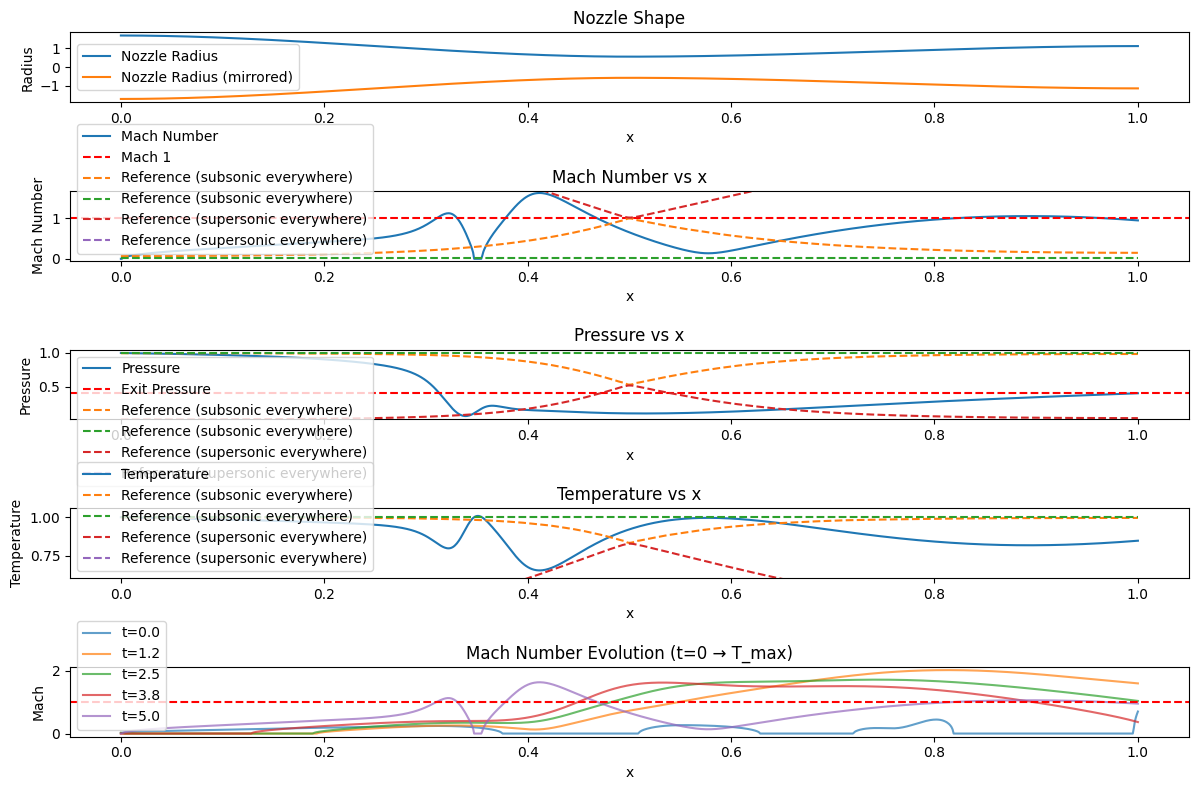

<Figure size 640x480 with 0 Axes>

In [ ]:
from itertools import product

plt.figure(figsize=(12, 8))
plt.subplot(5, 1, 1)
r = np.sqrt(get_area(torch.tensor(x, device=device)).cpu().numpy() / np.pi)
plt.plot(x, r, label="Nozzle Radius")
plt.plot(x, -r, label="Nozzle Radius (mirrored)")
plt.title("Nozzle Shape")
plt.xlabel("x")
plt.ylabel("Radius")
plt.legend()

M_ref_sup, M_ref_sub, p_ref_sup, p_ref_sub, t_ref_sup, t_ref_sub = map(
    lambda x: get_reference(eval_points.cpu(), x[0], x[1]),
    product(["M", "p", "T"], ["supersonic", "subsonic"]),
)


plt.subplot(5, 1, 2)
plt.plot(x, M, label="Mach Number")
plt.axhline(1, color="red", linestyle="--", label="Mach 1")
plt.plot(x, M_ref_sub, label="Reference (subsonic everywhere)", linestyle="dashed")
plt.plot(x, M_ref_sup, label="Reference (supersonic everywhere)", linestyle="dashed")
plt.title("Mach Number vs x")
plt.xlabel("x")
plt.ylabel("Mach Number")
plt.ylim(M.min() - 0.05, M.max() + 0.05)
plt.legend()

plt.subplot(5, 1, 3)
plt.plot(x, p, label="Pressure")
plt.axhline(p_exit, color="red", linestyle="--", label="Exit Pressure")
plt.plot(x, p_ref_sub, label="Reference (subsonic everywhere)", linestyle="dashed")
plt.plot(x, p_ref_sup, label="Reference (supersonic everywhere)", linestyle="dashed")
plt.title("Pressure vs x")
plt.xlabel("x")
plt.ylabel("Pressure")
plt.ylim(p.min() - 0.05, p.max() + 0.05)
plt.legend()

plt.subplot(5, 1, 4)
plt.plot(x, T, label="Temperature")
plt.plot(x, t_ref_sub, label="Reference (subsonic everywhere)", linestyle="dashed")
plt.plot(x, t_ref_sup, label="Reference (supersonic everywhere)", linestyle="dashed")
plt.title("Temperature vs x")
plt.xlabel("x")
plt.ylabel("Temperature")
plt.ylim(T.min() - 0.05, T.max() + 0.05)
plt.legend()

plt.subplot(5, 1, 5)
t_slices = [0.0, maximum_temp * 0.25, maximum_temp * 0.5, maximum_temp * 0.75, maximum_temp]
for t_val in t_slices:
    t_slice = torch.full((1000, 1), t_val, device=device)
    pts = torch.cat([x_lin, t_slice], dim=1).requires_grad_(True)
    with torch.enable_grad():
        out_slice = model(pts).detach().cpu().numpy()
    t_slice_var = out_slice[:, 3]
    M_slice = np.sqrt(np.maximum((2 / (gamma - 1)) * (1 / t_slice_var - 1), 0))
    plt.plot(x, M_slice, label=f"t={t_val:.1f}", alpha=0.7)
plt.axhline(1, color="red", linestyle="--")
plt.title("Mach Number Evolution (t=0 → T_max)")
plt.xlabel("x")
plt.ylabel("Mach")
plt.legend()

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

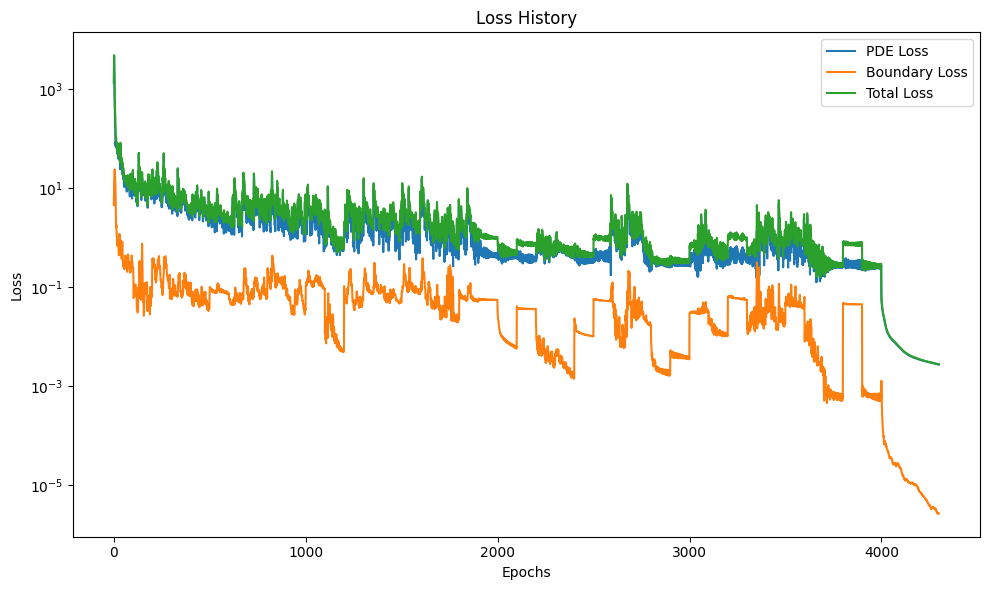

In [ ]:
#plot the loss history, for pde, boundary and total
plt.figure(figsize=(10, 6))
history_array = np.array(loss_history)
plt.plot(history_array[:, 0], label="PDE Loss")
plt.plot(history_array[:, 1], label="Boundary Loss")
plt.plot(history_array[:, 2], label="Total Loss")
plt.yscale("log")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss History")
plt.legend()
plt.tight_layout()
plt.show()